In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\SHIVANGI SHUKLA\OneDrive\Documents\Bank_Churn_Prediction\.venv\Scripts\python.exe
3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("All imports successful!")

Pandas: 3.0.6
NumPy: 2.5.3
Scikit-learn: 1.9.1
All imports successful!


In [4]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("../data/European_Bank.csv")

# Display the first 5 rows
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (10000, 14)

Column names:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
Year                 int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,10000.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


Exited
0    7963
1    2037
Name: count, dtype: int64

Overall churn rate: 20.37%


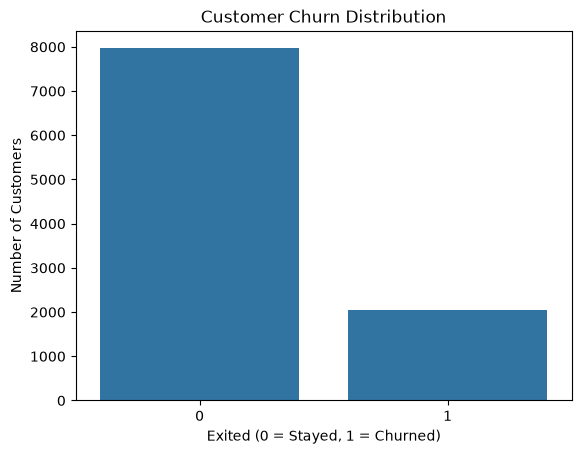

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count customers by churn status
print(df["Exited"].value_counts())

# Churn percentage
churn_rate = df["Exited"].mean() * 100
print(f"\nOverall churn rate: {churn_rate:.2f}%")

# Visualization
sns.countplot(data=df, x="Exited")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

print("\nCredit Card:")
print(df["HasCrCard"].value_counts())

print("\nActive Member:")
print(df["IsActiveMember"].value_counts())

print("\nNumber of Products:")
print(df["NumOfProducts"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Credit Card:
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

Active Member:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

Number of Products:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [10]:
# Churn rate by geography
print("Churn rate by Geography:")
print(df.groupby("Geography")["Exited"].mean().sort_values(ascending=False))

print("\nChurn rate by Gender:")
print(df.groupby("Gender")["Exited"].mean().sort_values(ascending=False))

print("\nChurn rate by Active Member status:")
print(df.groupby("IsActiveMember")["Exited"].mean())

print("\nChurn rate by Number of Products:")
print(df.groupby("NumOfProducts")["Exited"].mean())

Churn rate by Geography:
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

Churn rate by Gender:
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

Churn rate by Active Member status:
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

Churn rate by Number of Products:
NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


In [11]:
numerical_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary"
]

df.groupby("Exited")[numerical_cols].mean().T

Exited,0,1
CreditScore,651.853196,645.351497
Age,37.408389,44.837997
Tenure,5.033279,4.932744
Balance,72745.296779,91108.539337
EstimatedSalary,99738.391772,101465.677531


In [12]:
df.groupby("Exited")[numerical_cols].median().T

Exited,0,1
CreditScore,653.00,646.00
Age,36.00,45.00
Tenure,5.00,5.00
Balance,92072.68,109349.29
EstimatedSalary,99645.04,102460.84


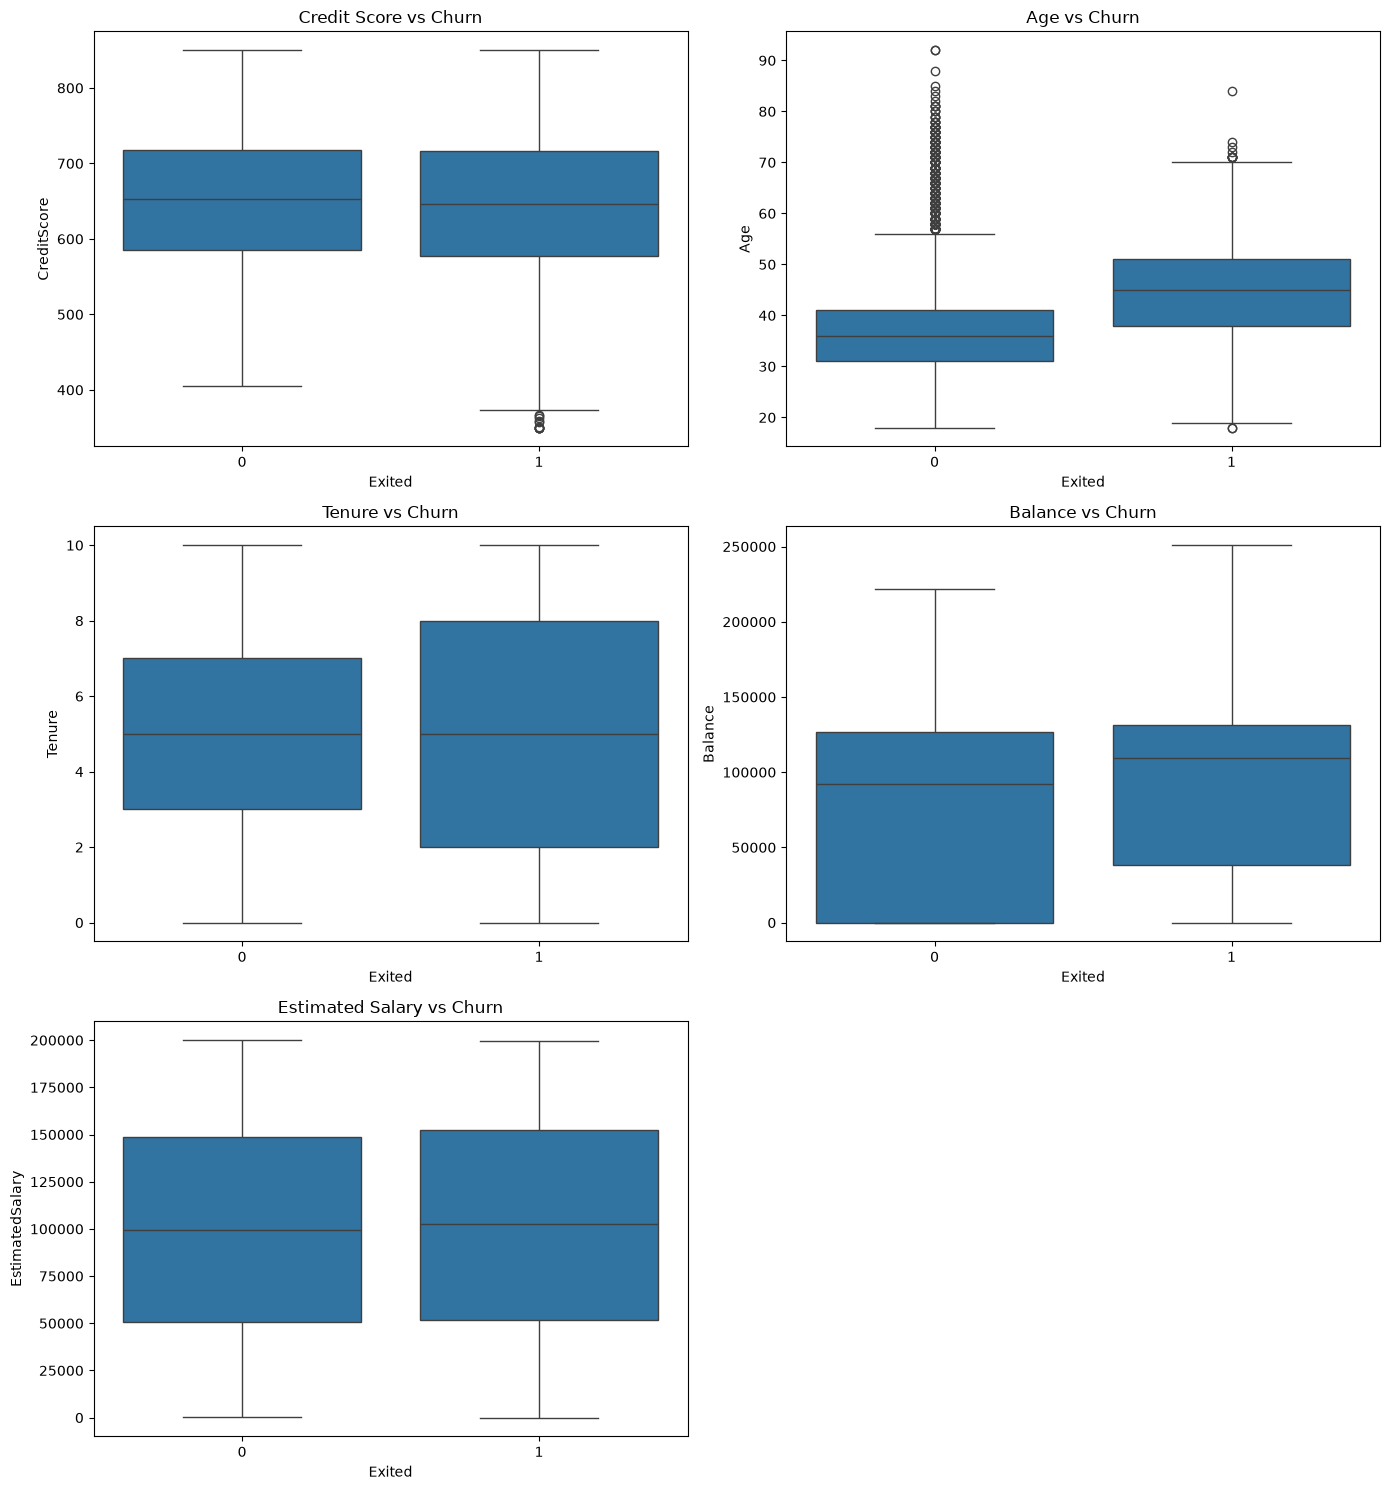

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

sns.boxplot(data=df, x="Exited", y="CreditScore", ax=axes[0, 0])
axes[0, 0].set_title("Credit Score vs Churn")

sns.boxplot(data=df, x="Exited", y="Age", ax=axes[0, 1])
axes[0, 1].set_title("Age vs Churn")

sns.boxplot(data=df, x="Exited", y="Tenure", ax=axes[1, 0])
axes[1, 0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Exited", y="Balance", ax=axes[1, 1])
axes[1, 1].set_title("Balance vs Churn")

sns.boxplot(data=df, x="Exited", y="EstimatedSalary", ax=axes[2, 0])
axes[2, 0].set_title("Estimated Salary vs Churn")

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

# Customer count and churn rate by age group
age_analysis = df.groupby("AgeGroup", observed=True)["Exited"].agg(
    Customers="count",
    Churn_Rate="mean"
)

age_analysis["Churn_Rate"] = age_analysis["Churn_Rate"] * 100

age_analysis

,Customers,Churn_Rate
AgeGroup,,
18-25,611,7.528642
26-35,3542,8.498024
36-45,3736,19.619914
46-55,1311,50.572082
56+,800,36.750000


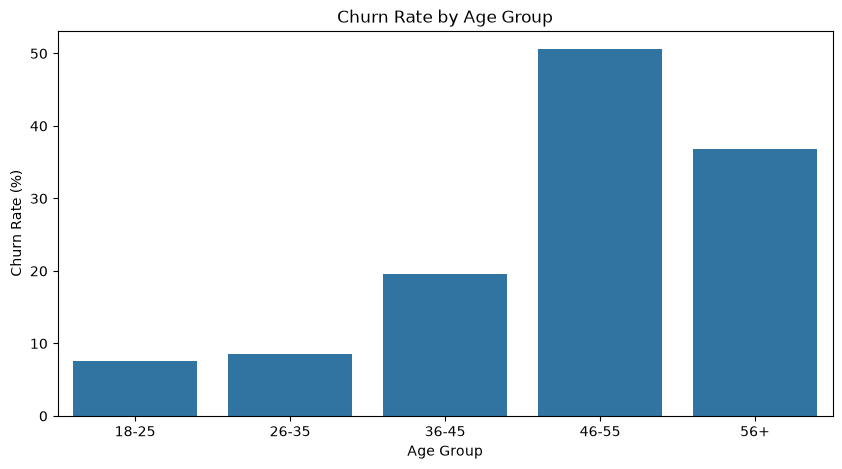

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_analysis.index,
    y=age_analysis["Churn_Rate"]
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [16]:
df["BalanceGroup"] = pd.cut(
    df["Balance"],
    bins=[-1, 50000, 100000, 150000, float("inf")],
    labels=["0-50K", "50K-100K", "100K-150K", "150K+"]
)

balance_analysis = df.groupby("BalanceGroup", observed=True)["Exited"].agg(
    Customers="count",
    Churn_Rate="mean"
)

balance_analysis["Churn_Rate"] = balance_analysis["Churn_Rate"] * 100

balance_analysis

,Customers,Churn_Rate
BalanceGroup,,
0-50K,3692,14.247021
50K-100K,1509,19.880716
100K-150K,3830,25.770235
150K+,969,23.116615


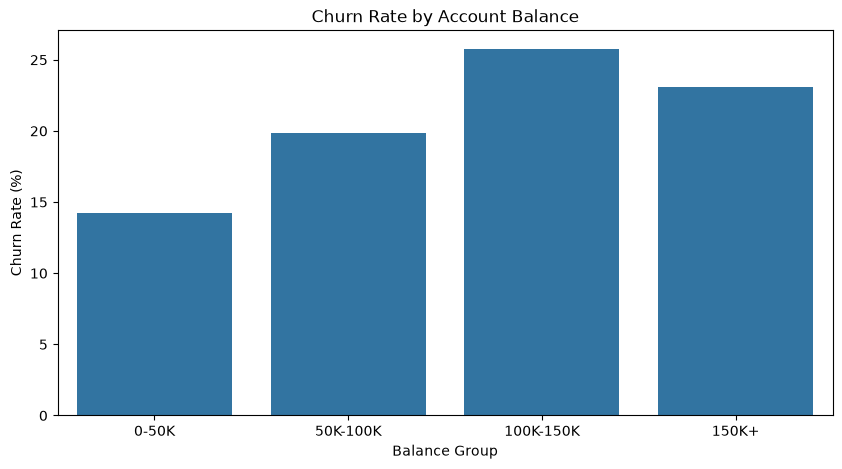

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=balance_analysis.index,
    y=balance_analysis["Churn_Rate"]
)

plt.title("Churn Rate by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\SHIVANGI SHUKLA\OneDrive\Documents\Bank_Churn_Prediction\.venv\Scripts\python.exe

Python version:
3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [3]:
# Check whether the dataframe exists

"df" in globals()

False

In [5]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Churn rate by Geography

geography_churn = df.groupby("Geography").agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

geography_churn["Churn_Rate"] = geography_churn["Churn_Rate"] * 100

geography_churn

,Customers,Churn_Rate
Geography,,
France,5014,16.154767
Germany,2509,32.443204
Spain,2477,16.673395


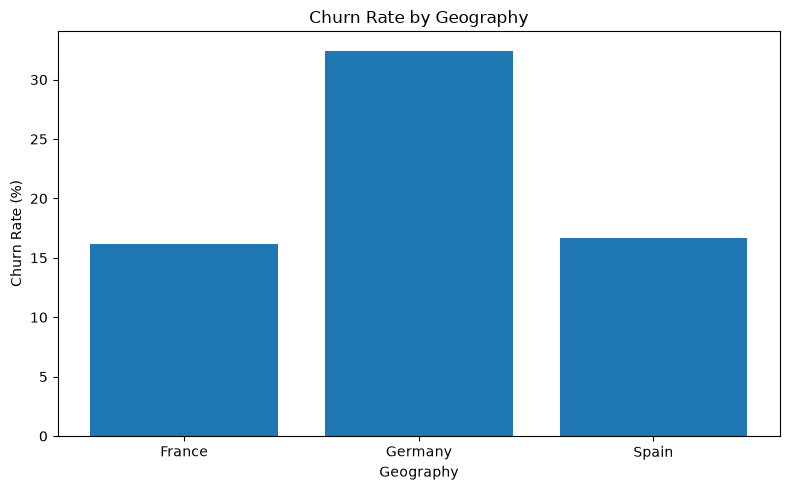

In [7]:
# Visualize churn rate by Geography

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    geography_churn.index,
    geography_churn["Churn_Rate"]
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

In [8]:
# Churn rate by Active Member status

active_churn = df.groupby("IsActiveMember").agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

active_churn["Churn_Rate"] = active_churn["Churn_Rate"] * 100

active_churn.index = active_churn.index.map({
    0: "Inactive",
    1: "Active"
})

active_churn

,Customers,Churn_Rate
IsActiveMember,,
Inactive,4849,26.850897
Active,5151,14.269074


In [9]:
# Churn rate by number of products

products_churn = df.groupby("NumOfProducts").agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

products_churn["Churn_Rate"] = products_churn["Churn_Rate"] * 100

products_churn

,Customers,Churn_Rate
NumOfProducts,,
1,5084,27.714398
2,4590,7.581699
3,266,82.706767
4,60,100.000000


In [10]:
# Create Credit Score groups

df["CreditScoreGroup"] = pd.cut(
    df["CreditScore"],
    bins=[0, 500, 600, 700, 800, 900],
    labels=["<500", "500-600", "600-700", "700-800", "800+"]
)

credit_churn = df.groupby(
    "CreditScoreGroup",
    observed=True
).agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

credit_churn["Churn_Rate"] = credit_churn["Churn_Rate"] * 100

credit_churn

,Customers,Churn_Rate
CreditScoreGroup,,
<500,643,23.639191
500-600,2423,21.172101
600-700,3818,19.722368
700-800,2471,19.910967
800+,645,19.689922


In [11]:
# Churn rate by Gender

gender_churn = df.groupby("Gender").agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

gender_churn["Churn_Rate"] = gender_churn["Churn_Rate"] * 100

gender_churn

,Customers,Churn_Rate
Gender,,
Female,4543,25.071539
Male,5457,16.455928


In [12]:
# Churn rate by Credit Card ownership

card_churn = df.groupby("HasCrCard").agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

card_churn["Churn_Rate"] = card_churn["Churn_Rate"] * 100

card_churn.index = card_churn.index.map({
    0: "No Credit Card",
    1: "Has Credit Card"
})

card_churn

,Customers,Churn_Rate
HasCrCard,,
No Credit Card,2945,20.814941
Has Credit Card,7055,20.184266


In [13]:
# Churn rate by Tenure

tenure_churn = df.groupby("Tenure").agg(
    Customers=("Exited", "count"),
    Churn_Rate=("Exited", "mean")
)

tenure_churn["Churn_Rate"] = tenure_churn["Churn_Rate"] * 100

tenure_churn

,Customers,Churn_Rate
Tenure,,
0,413,23.002421
1,1035,22.415459
2,1048,19.179389
3,1009,21.110010
4,989,20.525784
5,1012,20.652174
6,967,20.268873
7,1028,17.217899
8,1025,19.219512


In [14]:
# Create modeling dataset

model_df = df.drop(
    columns=[
        "Year",
        "CustomerId",
        "Surname",
        "Exited",
        "CreditScoreGroup"
    ]
)

X = model_df.copy()
y = df["Exited"]

print("Features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Feature shape: (10000, 10)
Target shape: (10000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (8000, 10)
Testing data: (2000, 10)

Training target distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

Testing target distribution:
Exited
0    1593
1     407
Name: count, dtype: int64


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical features

categorical_features = ["Geography", "Gender"]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Preprocessor created successfully.
Numerical features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical features: ['Geography', 'Gender']


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [18]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test)

# Get probability of churn (0 to 1)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 2000


In [21]:
# Generate probability predictions for ROC-AUC

y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully.")
print("Number of probability predictions:", len(y_pred_proba))

Probability predictions generated successfully.
Number of probability predictions: 2000


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Display results
print("Model Evaluation Results")
print("-" * 30)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Evaluation Results
------------------------------
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1 Score  : 0.2836
ROC-AUC   : 0.7748

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Confusion Matrix:
[[1540   53]
 [ 331   76]]


In [24]:
import sklearn
import scipy
import numpy

print("scikit-learn version:", sklearn.__version__)
print("SciPy version:", scipy.__version__)
print("NumPy version:", numpy.__version__)

scikit-learn version: 1.9.1
SciPy version: 1.18.1
NumPy version: 2.5.3


In [25]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully.")

Decision Tree imported successfully.


In [27]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=6,
            random_state=42
        ))
    ]
)

# Train the model

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [28]:
# Generate Decision Tree predictions

dt_pred = decision_tree_model.predict(X_test)
dt_pred_proba = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")
print("Number of predictions:", len(dt_pred))

Decision Tree predictions generated successfully.
Number of predictions: 2000


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_pred_proba)

# Display results
print("Decision Tree Model Evaluation Results")
print("-" * 40)
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")
print(f"ROC-AUC   : {dt_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Model Evaluation Results
----------------------------------------
Accuracy  : 0.8605
Precision : 0.7759
Recall    : 0.4423
F1 Score  : 0.5634
ROC-AUC   : 0.8402

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Confusion Matrix:
[[1541   52]
 [ 227  180]]


In [30]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, dt_accuracy],
    "Precision": [precision, dt_precision],
    "Recall": [recall, dt_recall],
    "F1 Score": [f1, dt_f1],
    "ROC-AUC": [roc_auc, dt_roc_auc]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774756
1,Decision Tree,0.8605,0.775862,0.442260,0.563380,0.840206


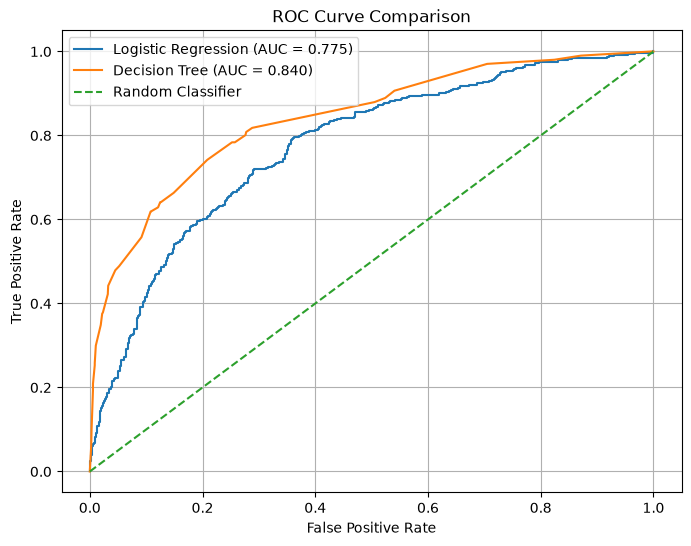

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_pred_proba)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_pred_proba)

# Calculate AUC
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression predictions
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_logistic))

print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, y_pred_logistic))


# Decision Tree predictions
y_pred_tree = decision_tree_model.predict(X_test)

print("\nDecision Tree Classification Report")
print(classification_report(y_test, y_pred_tree))

print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_test, y_pred_tree))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Logistic Regression Confusion Matrix
[[1540   53]
 [ 331   76]]

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Decision Tree Confusion Matrix
[[1541   52]
 [ 227  180]]


In [33]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Training predictions
y_train_pred_tree = decision_tree_model.predict(X_train)
y_train_prob_tree = decision_tree_model.predict_proba(X_train)[:, 1]

# Testing predictions
y_test_pred_tree = decision_tree_model.predict(X_test)
y_test_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Training Accuracy:",
      accuracy_score(y_train, y_train_pred_tree))

print("Decision Tree Testing Accuracy:",
      accuracy_score(y_test, y_test_pred_tree))

print("Decision Tree Training AUC:",
      roc_auc_score(y_train, y_train_prob_tree))

print("Decision Tree Testing AUC:",
      roc_auc_score(y_test, y_test_prob_tree))

Decision Tree Training Accuracy: 0.868125
Decision Tree Testing Accuracy: 0.8605
Decision Tree Training AUC: 0.8627812503009699
Decision Tree Testing AUC: 0.8402061537654758


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get the actual Decision Tree from the pipeline
tree_model = decision_tree_model.named_steps["classifier"]

# Get feature importance
importance = tree_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

                   Feature  Importance
1                 num__Age    0.388051
4       num__NumOfProducts    0.301110
6      num__IsActiveMember    0.121630
3             num__Balance    0.106800
8   cat__Geography_Germany    0.054947
7     num__EstimatedSalary    0.011985
0         num__CreditScore    0.010584
2              num__Tenure    0.002816
9     cat__Geography_Spain    0.001342
10        cat__Gender_Male    0.000734
5           num__HasCrCard    0.000000


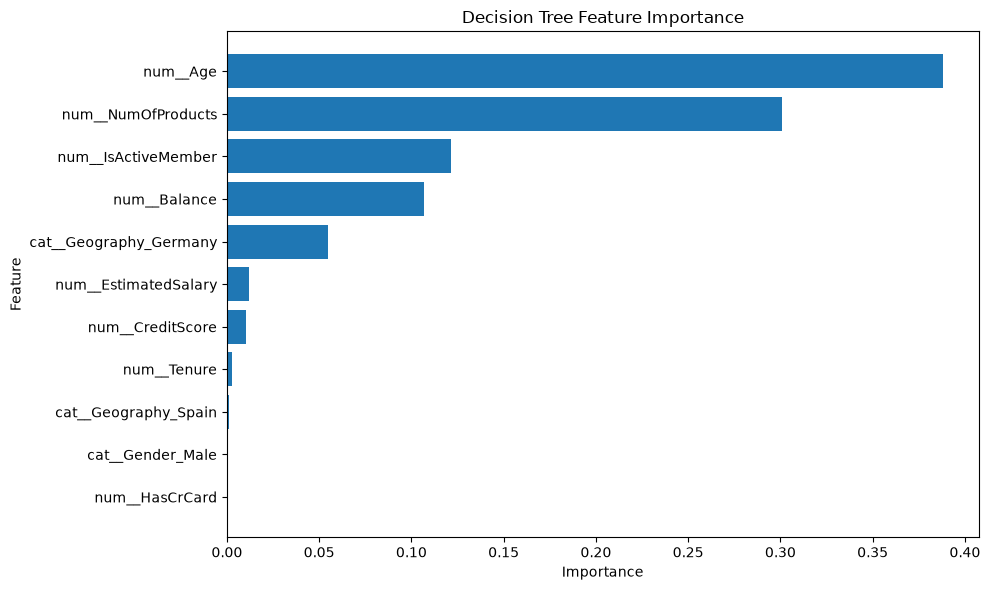

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
print(feature_importance_df.to_string(index=False))

               Feature  Importance
              num__Age    0.388051
    num__NumOfProducts    0.301110
   num__IsActiveMember    0.121630
          num__Balance    0.106800
cat__Geography_Germany    0.054947
  num__EstimatedSalary    0.011985
      num__CreditScore    0.010584
           num__Tenure    0.002816
  cat__Geography_Spain    0.001342
      cat__Gender_Male    0.000734
        num__HasCrCard    0.000000


In [38]:
import joblib

# Save the complete Decision Tree pipeline
joblib.dump(decision_tree_model, "bank_churn_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [39]:
# Example customer
new_customer = pd.DataFrame({
    "CreditScore": [650],
    "Geography": ["Germany"],
    "Gender": ["Female"],
    "Age": [45],
    "Tenure": [3],
    "Balance": [85000],
    "NumOfProducts": [1],
    "HasCrCard": [1],
    "IsActiveMember": [0],
    "EstimatedSalary": [90000]
})

# Predict churn
prediction = decision_tree_model.predict(new_customer)

# Predict churn probability
probability = decision_tree_model.predict_proba(new_customer)

print("Churn Prediction:", prediction[0])
print("Probability of Churn:", probability[0][1])

Churn Prediction: 1
Probability of Churn: 0.6721311475409836


In [40]:
# Convert prediction into business-friendly result

churn_prediction = "Likely to Churn" if prediction[0] == 1 else "Likely to Stay"
churn_probability = probability[0][1] * 100

print("Customer Churn Prediction")
print("-------------------------")
print("Prediction:", churn_prediction)
print(f"Churn Probability: {churn_probability:.2f}%")

Customer Churn Prediction
-------------------------
Prediction: Likely to Churn
Churn Probability: 67.21%


In [41]:
# Final model performance summary

print("FINAL MODEL: DECISION TREE")
print("=" * 40)

print(f"Training Accuracy : {0.868125:.4f}")
print(f"Testing Accuracy  : {0.8605:.4f}")
print(f"Training AUC      : {0.862781:.4f}")
print(f"Testing AUC       : {0.840206:.4f}")

print("\nChurn Class Performance")
print("-" * 40)
print("Precision : 0.78")
print("Recall    : 0.44")
print("F1-Score  : 0.56")

print("\nBusiness Interpretation")
print("-" * 40)
print("The model identifies customers at higher risk of churn")
print("and can support proactive customer retention strategies.")

FINAL MODEL: DECISION TREE
Training Accuracy : 0.8681
Testing Accuracy  : 0.8605
Training AUC      : 0.8628
Testing AUC       : 0.8402

Churn Class Performance
----------------------------------------
Precision : 0.78
Recall    : 0.44
F1-Score  : 0.56

Business Interpretation
----------------------------------------
The model identifies customers at higher risk of churn
and can support proactive customer retention strategies.


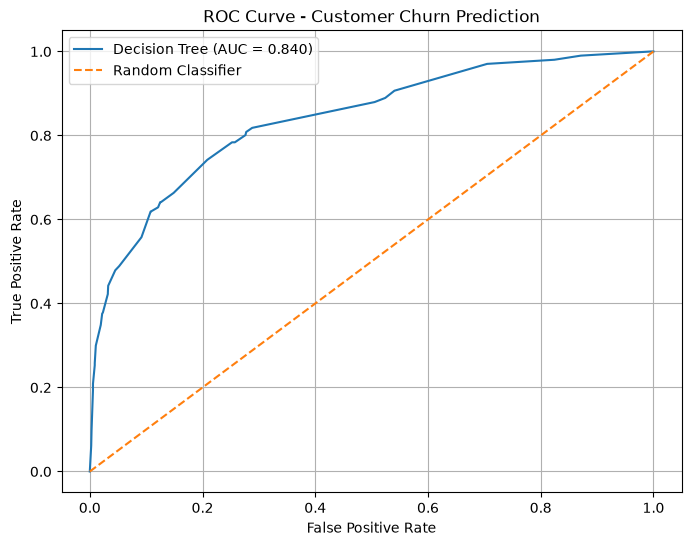

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the test set
y_test_proba = decision_tree_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid(True)

plt.show()

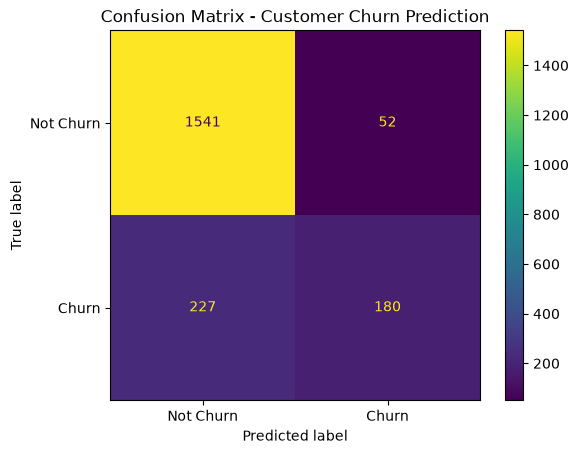

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_test_pred = decision_tree_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

Feature Importance:


,Feature,Importance
1,num__Age,0.388051
4,num__NumOfProducts,0.301110
6,num__IsActiveMember,0.121630
3,num__Balance,0.106800
8,cat__Geography_Germany,0.054947
7,num__EstimatedSalary,0.011985
0,num__CreditScore,0.010584
2,num__Tenure,0.002816
9,cat__Geography_Spain,0.001342
10,cat__Gender_Male,0.000734


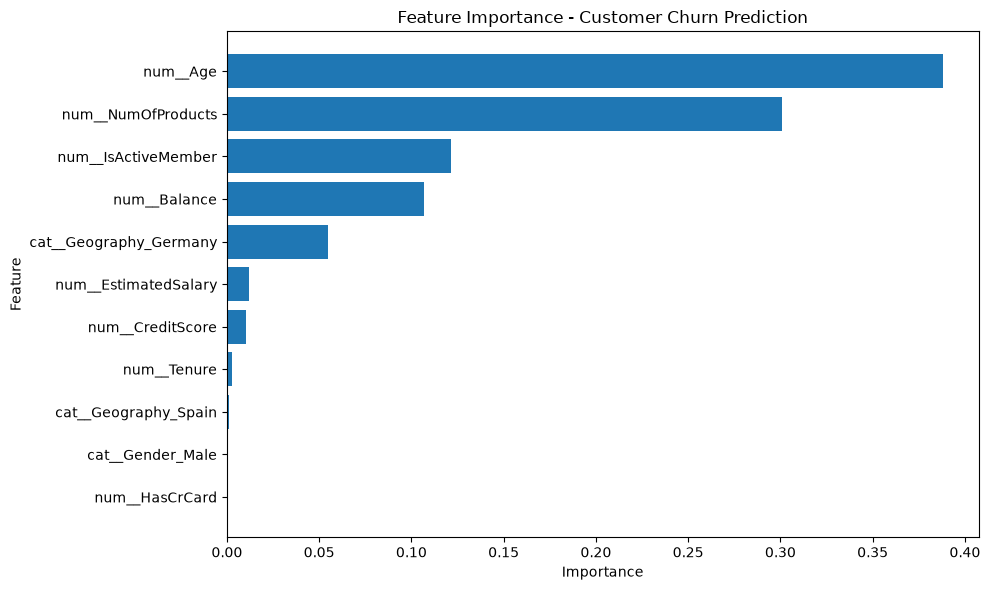

In [45]:
# Feature Importance Visualization

import pandas as pd
import matplotlib.pyplot as plt

# Extract the Decision Tree from the pipeline
tree_model = decision_tree_model.named_steps["classifier"]

# Get feature importance
feature_importance = tree_model.feature_importances_

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print("Feature Importance:")
display(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Customer Churn Prediction")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [47]:
# Final Customer Churn Prediction Function

def predict_customer_churn(
    CreditScore,
    Geography,
    Gender,
    Age,
    Tenure,
    Balance,
    NumOfProducts,
    HasCrCard,
    IsActiveMember,
    EstimatedSalary
):
    
    # Create customer input
    customer = pd.DataFrame({
        "CreditScore": [CreditScore],
        "Geography": [Geography],
        "Gender": [Gender],
        "Age": [Age],
        "Tenure": [Tenure],
        "Balance": [Balance],
        "NumOfProducts": [NumOfProducts],
        "HasCrCard": [HasCrCard],
        "IsActiveMember": [IsActiveMember],
        "EstimatedSalary": [EstimatedSalary]
    })
    
    # Prediction
    prediction = decision_tree_model.predict(customer)[0]
    
    # Churn probability
    probability = decision_tree_model.predict_proba(customer)[0][1]
    
    # Risk level
    if probability >= 0.70:
        risk_level = "High"
    elif probability >= 0.40:
        risk_level = "Medium"
    else:
        risk_level = "Low"
    
    # Display result
    print("CUSTOMER CHURN PREDICTION")
    print("-" * 35)
    
    if prediction == 1:
        print("Prediction        : Likely to Churn")
    else:
        print("Prediction        : Likely to Stay")
    
    print(f"Churn Probability : {probability:.2%}")
    print(f"Risk Level        : {risk_level}")

In [48]:
# Example customer

predict_customer_churn(
    CreditScore=619,
    Geography="France",
    Gender="Female",
    Age=42,
    Tenure=2,
    Balance=120000,
    NumOfProducts=1,
    HasCrCard=1,
    IsActiveMember=0,
    EstimatedSalary=101348.88
)

CUSTOMER CHURN PREDICTION
-----------------------------------
Prediction        : Likely to Stay
Churn Probability : 9.00%
Risk Level        : Low


## Business Insights

The customer churn prediction model provides actionable insights for
proactive customer retention.

### Key Findings

- The Decision Tree achieved a testing accuracy of 86.05%.
- The testing ROC-AUC was 0.8402, indicating good classification ability.
- Age was the most important feature in the model, with an importance of 38.81%.
- Number of products was the second most important feature, with an importance of 30.11%.
- Active membership and account balance were also important predictors.
- The model can identify customers with elevated churn risk and support targeted
  retention strategies.

### Business Application

Banks can use the model to identify customers at higher risk of leaving and
prioritize them for proactive engagement. Possible actions include personalized
offers, relationship-manager outreach, product recommendations, and customer
service interventions.

The model should be used as a decision-support tool rather than as the sole
basis for customer decisions.